In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/stephanmatzka/predictive-maintenance-dataset-ai4i-2020/ai4i2020.csv


In [2]:
# Loading the dataset

df = pd.read_csv('/kaggle/input/datasets/stephanmatzka/predictive-maintenance-dataset-ai4i-2020/ai4i2020.csv')

df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
# Getting the Overview of dataset

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

Rows: 10000
Columns: 14
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtyp

In [4]:
# Checking the missing value

df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [5]:
# As the Dataset has no issing values, now we can drop the columns that are not useful for analysing the pattern

df.drop(
    ['UDI','Product ID'],
    axis=1,
    inplace=True
)

# Check the df.drop is worked by retriving the data
df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [6]:
# Renaming the columns for the convinence 

df.columns = [
    'Type',
    'AirTemp',
    'ProcessTemp',
    'RPM',
    'Torque',
    'ToolWear',
    'MachineFailure',
    'TWF',
    'HDF',
    'PWF',
    'OSF',
    'RNF'
]

df.head()

,Type,AirTemp,ProcessTemp,RPM,Torque,ToolWear,MachineFailure,TWF,HDF,PWF,OSF,RNF
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [7]:
# Stat
df.describe()

,AirTemp,ProcessTemp,RPM,Torque,ToolWear,MachineFailure,TWF,HDF,PWF,OSF,RNF
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


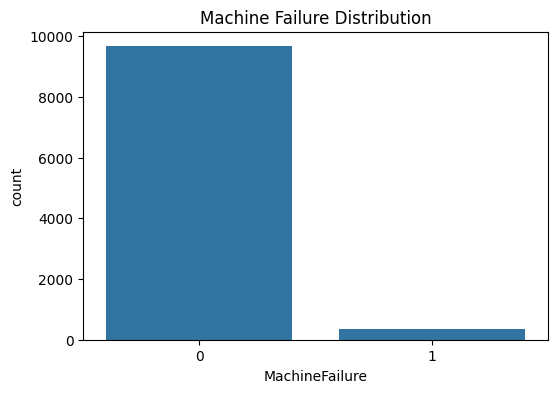

In [8]:
# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Failure Distribution
plt.figure(figsize=(6,4))

sns.countplot(
    x='MachineFailure',
    data=df
)

plt.title('Machine Failure Distribution')
plt.show()

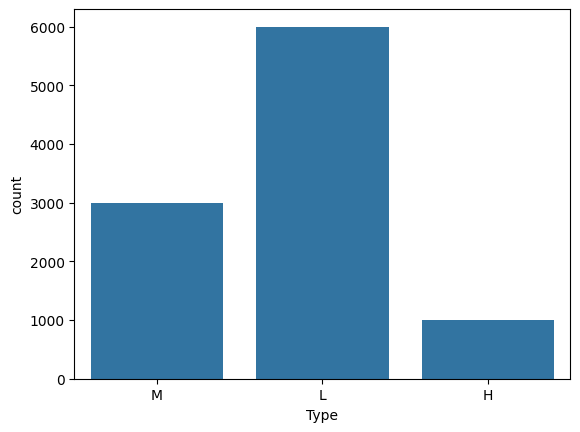

In [9]:
# Product type Distribution
sns.countplot(
    x='Type',
    data=df
)

plt.show()

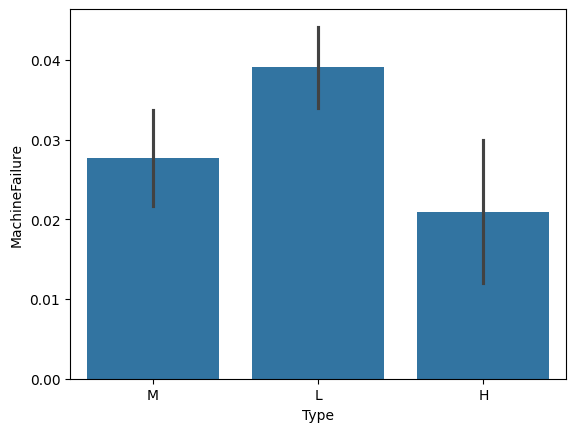

In [10]:
# Failure by product
pd.crosstab(
    df['Type'],
    df['MachineFailure']
)

# Visual
sns.barplot(
    x='Type',
    y='MachineFailure',
    data=df
)
plt.show()

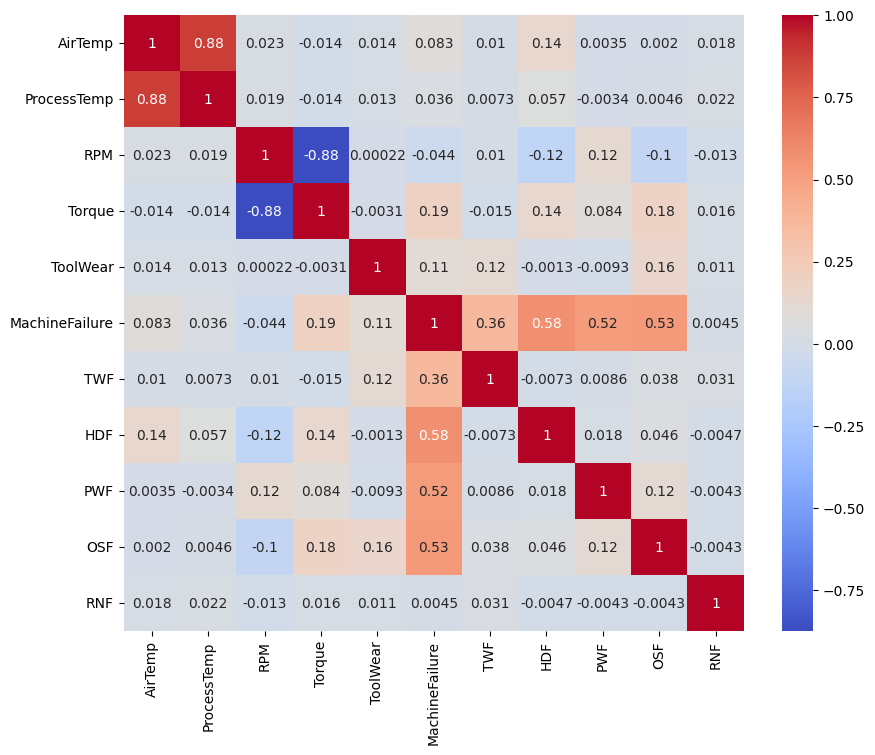

In [11]:
# Correlation Heatmap
plt.figure(figsize=(10,8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

In [12]:
# Analysing the Failure Mode
failure_modes = {
    'TWF':'Tool Wear Failure',
    'HDF':'Heat Dissipation Failure',
    'PWF':'Power Failure',
    'OSF':'Overstrain Failure',
    'RNF':'Random Failure'
}

for col,name in failure_modes.items():
    print(name,':',df[col].sum())

Tool Wear Failure : 46
Heat Dissipation Failure : 115
Power Failure : 95
Overstrain Failure : 98
Random Failure : 19


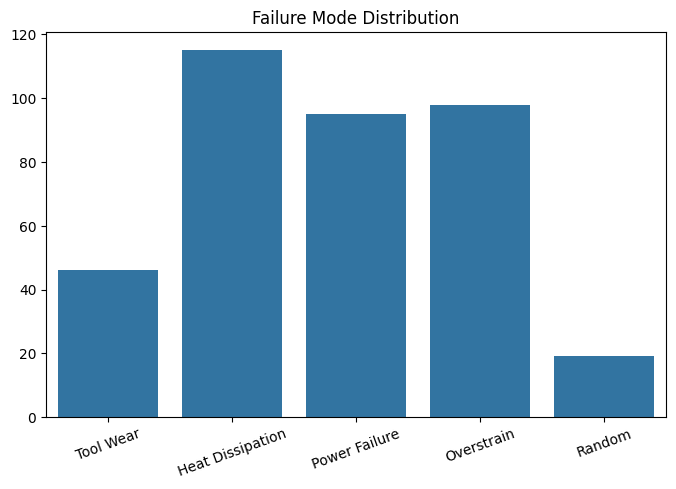

In [13]:
# Visualizing the failure mode
failure_counts = {
    'Tool Wear': df['TWF'].sum(),
    'Heat Dissipation': df['HDF'].sum(),
    'Power Failure': df['PWF'].sum(),
    'Overstrain': df['OSF'].sum(),
    'Random': df['RNF'].sum()
}

plt.figure(figsize=(8,5))

sns.barplot(
    x=list(failure_counts.keys()),
    y=list(failure_counts.values())
)

plt.title("Failure Mode Distribution")
plt.xticks(rotation=20)
plt.show()

In [14]:
# Failure rate by product type
pd.crosstab(
    df['Type'],
    df['MachineFailure']
)


MachineFailure,0,1
Type,,
H,982,21
L,5765,235
M,2914,83


In [15]:
failure_by_type = (
    df.groupby('Type')['MachineFailure']
    .mean()*100
)

failure_by_type

Type
H    2.093719
L    3.916667
M    2.769436
Name: MachineFailure, dtype: float64

In [16]:
for mode in ['TWF','HDF','PWF','OSF','RNF']:
    print("\n",mode)
    print(pd.crosstab(df['Type'],df[mode]))


 TWF
TWF      0   1
Type          
H      996   7
L     5975  25
M     2983  14

 HDF
HDF      0   1
Type          
H      995   8
L     5924  76
M     2966  31

 PWF
PWF      0   1
Type          
H      998   5
L     5941  59
M     2966  31

 OSF
OSF      0   1
Type          
H     1001   2
L     5913  87
M     2988   9

 RNF
RNF      0   1
Type          
H      999   4
L     5987  13
M     2995   2


In [17]:
# Temp difference
df['TempDiff'] = (
    df['ProcessTemp']
    - df['AirTemp']
)

# Power with torque and RPM
df['Power'] = (
    (2*np.pi*df['RPM']/60)
    * df['Torque']
)

# Overstrain Index
df['OverstrainIndex'] = (
    df['ToolWear']
    * df['Torque']
)

In [18]:
# Heat Dissipation Risk
df['HDF_Risk'] = np.where(
    (df['ProcessTemp'] - df['AirTemp'] < 8.6)
    &
    (df['RPM'] < 1380),
    1,
    0
)
df['PWF_Risk'] = np.where(
    (df['Power'] < 3500)
    |
    (df['Power'] > 9000),
    1,
    0
)

In [19]:
# Custom Equipment Health Index
df['HealthScore'] = (
    100
    - df['ToolWear']*0.1
    - df['Torque']*0.2
)

In [20]:
df['HealthScore'] = (
    df['HealthScore']
    .clip(0,100)
)

df['Status'] = pd.cut(
    df['HealthScore'],
    bins=[0,50,75,100],
    labels=[
        'Critical',
        'Warning',
        'Healthy'
    ]
)

In [21]:
# Verifing the Overlap of failure
df['FailureCount'] = (
    df[['TWF','HDF','PWF','OSF','RNF']]
    .sum(axis=1)
)

df['FailureCount'].value_counts().sort_index()

FailureCount
0    9652
1     324
2      23
3       1
Name: count, dtype: int64

In [22]:
# Proper Failure Cause column
def failure_causes(row):

    causes = []

    if row['TWF'] == 1:
        causes.append('Tool Wear')

    if row['HDF'] == 1:
        causes.append('Heat Dissipation')

    if row['PWF'] == 1:
        causes.append('Power')

    if row['OSF'] == 1:
        causes.append('Overstrain')

    if row['RNF'] == 1:
        causes.append('Random')

    if len(causes) == 0:
        return 'No Failure'

    return ', '.join(causes)

df['FailureCause'] = df.apply(
    failure_causes,
    axis=1
)

df['FailureCause'].value_counts().head(20)

FailureCause
No Failure                      9652
Heat Dissipation                 106
Power                             80
Overstrain                        78
Tool Wear                         42
Random                            18
Power, Overstrain                 11
Heat Dissipation, Overstrain       6
Heat Dissipation, Power            3
Tool Wear, Overstrain              2
Tool Wear, Random                  1
Tool Wear, Power, Overstrain       1
Name: count, dtype: int64

In [23]:
df.groupby('Type')['MachineFailure'].agg(
    ['count','sum','mean']
)

,count,sum,mean
Type,,,
H,1003,21,0.020937
L,6000,235,0.039167
M,2997,83,0.027694


In [24]:
# Testing whether failed machines have higher tool wear
print(df.groupby('MachineFailure')['ToolWear'].mean())

# Analysing the cause of failure is mechanical stress
print(df.groupby('MachineFailure')['RPM'].mean())
print(df.groupby('MachineFailure')['Torque'].mean())

MachineFailure
0    106.693717
1    143.781711
Name: ToolWear, dtype: float64
MachineFailure
0    1540.260014
1    1496.486726
Name: RPM, dtype: float64
MachineFailure
0    39.629655
1    50.168142
Name: Torque, dtype: float64


In [25]:
failure_modes = ['TWF','HDF','PWF','OSF','RNF']

for mode in failure_modes:
    rate = (df[mode].sum()/len(df))*100
    print(f"{mode}: {rate:.2f}%")

TWF: 0.46%
HDF: 1.15%
PWF: 0.95%
OSF: 0.98%
RNF: 0.19%


In [26]:
pd.crosstab(
    df['Type'],
    df['FailureCause']
)

FailureCause,Heat Dissipation,"Heat Dissipation, Overstrain","Heat Dissipation, Power",No Failure,Overstrain,Power,"Power, Overstrain",Random,Tool Wear,"Tool Wear, Overstrain","Tool Wear, Power, Overstrain","Tool Wear, Random"
Type,,,,,,,,,,,,
H,8,0,0,979,1,4,0,4,6,0,1,0
L,68,6,2,5757,73,49,8,12,24,0,0,1
M,30,0,1,2916,4,27,3,2,12,2,0,0


# Feature Engineering

In [27]:
def get_failure_type(row):

    if row['TWF']==1:
        return 'Tool Wear'

    elif row['HDF']==1:
        return 'Heat Dissipation'

    elif row['PWF']==1:
        return 'Power Failure'

    elif row['OSF']==1:
        return 'Overstrain'

    elif row['RNF']==1:
        return 'Random'

    else:
        return 'No Failure'

df['FailureClass'] = df.apply(
    get_failure_type,
    axis=1
)
df['FailureClass'].value_counts()

FailureClass
No Failure          9652
Heat Dissipation     115
Power Failure         91
Overstrain            78
Tool Wear             46
Random                18
Name: count, dtype: int64

In [28]:
df.columns.tolist()

['Type',
 'AirTemp',
 'ProcessTemp',
 'RPM',
 'Torque',
 'ToolWear',
 'MachineFailure',
 'TWF',
 'HDF',
 'PWF',
 'OSF',
 'RNF',
 'TempDiff',
 'Power',
 'OverstrainIndex',
 'HDF_Risk',
 'PWF_Risk',
 'HealthScore',
 'Status',
 'FailureCount',
 'FailureCause',
 'FailureClass']

# ***Model 1 - Failure Detection***

In [29]:
# Encoding
df = pd.get_dummies(
    df,
    columns=['Type'],
    drop_first=True,
    dtype=int
)

# Feature
features = [
    'AirTemp',
    'ProcessTemp',
    'RPM',
    'Torque',
    'ToolWear',
    'TempDiff',
    'Power',
    'OverstrainIndex',
    'Type_L',
    'Type_M'
]
# Target Value
y = df['MachineFailure']

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X = df[features]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)

In [31]:
from sklearn.metrics import classification_report

pred = model.predict(X_test)

print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1932
           1       0.96      0.76      0.85        68

    accuracy                           0.99      2000
   macro avg       0.98      0.88      0.92      2000
weighted avg       0.99      0.99      0.99      2000



           Feature  Importance
2              RPM    0.204868
3           Torque    0.185777
6            Power    0.182695
4         ToolWear    0.137117
7  OverstrainIndex    0.120140
5         TempDiff    0.085888
0          AirTemp    0.047752
1      ProcessTemp    0.027443
9           Type_M    0.004330
8           Type_L    0.003989


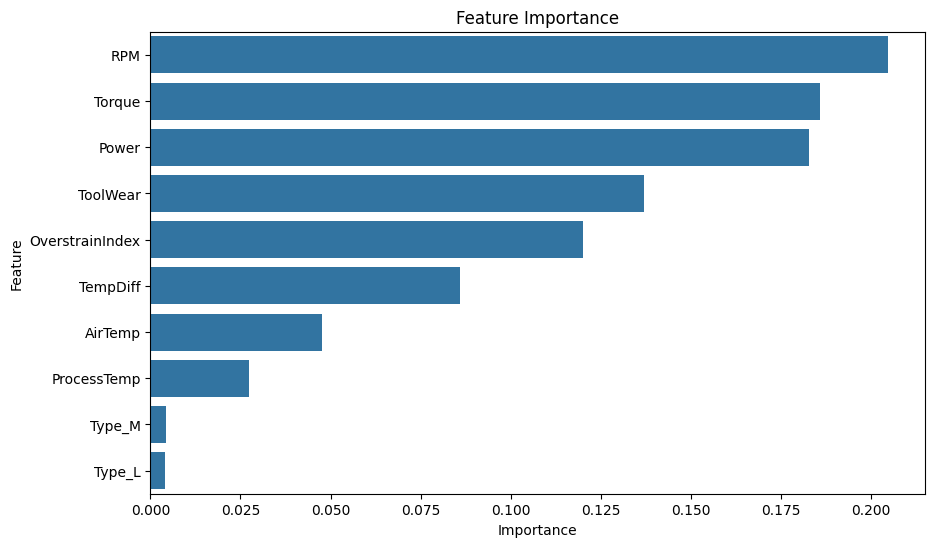

In [32]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(
    by='Importance',
    ascending=False
)

print(importance)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title('Feature Importance')
plt.show()

In [33]:
pred = model.predict(X_test)

In [34]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred)

print(cm)

[[1930    2]
 [  16   52]]
